<a href="https://colab.research.google.com/github/emcgeever-husky/Econ3916/blob/main/Assignment%204/The_Predictive_Architecture_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as py
import missingno as msno
import statsmodels.formula.api as smf
import statsmodels.api as sm
import category_encoders as ce
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [110]:
## Datasets
vitals_url = 'https://raw.githubusercontent.com/emcgeever-husky/Econ3916/f73665bdb542e63f56bf9364a257d5aff3fe8311/Assignment%204/OmniCare_Clinical_Vitals.csv'
telemetry_url = 'https://raw.githubusercontent.com/emcgeever-husky/Econ3916/f73665bdb542e63f56bf9364a257d5aff3fe8311/Assignment%204/OmniCare_Telemetry_Data.csv'

vitals_df = pd.read_csv(vitals_url)
telemetry_df = pd.read_csv(telemetry_url)


In [111]:
vitals_df

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0
...,...,...,...,...,...,...
4995,5995,169.3,72.7,25.39,106.0,76.0
4996,5996,180.7,56.6,17.34,139.0,100.0
4997,5997,216.7,99.4,21.16,140.0,96.0
4998,5998,182.1,77.9,23.48,107.0,83.0


In [112]:
telemetry_df

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34
...,...,...,...,...,...,...,...,...
4995,5995,1,0.140,52.2,M96.598,0.58,3.7,1150.29
4996,5996,0,0.152,76.0,M63.490,0.68,17.6,1739.46
4997,5997,0,0.363,91.0,C64.505,0.77,2.3,1713.14
4998,5998,0,0.118,53.5,A23.926,0.55,9.2,1589.11


## Phase 1: Causal Topology and Multicollinearity Forensics

### 1.1 Diagnosing Spurious Clinical Signals (DAGs)

In [113]:
# Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)
High_Deductible_Insurance_Plan = telemetry_df['High_Deductible_Insurance_Plan']
Inpatient_Admission_Rate = telemetry_df['Inpatient_Admission_Rate']

model_naive = smf.ols('Inpatient_Admission_Rate ~ High_Deductible_Insurance_Plan', data=telemetry_df).fit()
print(model_naive.summary())

                               OLS Regression Results                               
Dep. Variable:     Inpatient_Admission_Rate   R-squared:                       0.091
Model:                                  OLS   Adj. R-squared:                  0.091
Method:                       Least Squares   F-statistic:                     499.2
Date:                      Tue, 24 Mar 2026   Prob (F-statistic):          1.77e-105
Time:                              04:07:52   Log-Likelihood:                 3560.0
No. Observations:                      5000   AIC:                            -7116.
Df Residuals:                          4998   BIC:                            -7103.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

The hidden confounder here is socio-economic status. lower status patients are simaltaniously more likely to be in higher deductable plans, because they are cheaper, and have worse baseline health outcomes from poorer diet, food insecurity, a well documented "health-gap" relationship. Because socio-economic status (SES) is included or controlled for, it inflates the correlation here.

In [114]:
"""
Socioeconomic Status (SES)
               /          \
              /             \
  High-Deductible             Inpatient
  Insurance Plan    ....>  Admission Rate
  (Treatment)       spurious   (Outcome)

"""

'\nSocioeconomic Status (SES)\n               /                        /               High-Deductible             Inpatient\n  Insurance Plan    ....>  Admission Rate\n  (Treatment)       spurious   (Outcome)\n\n'

### 1.2 The Variance Inflation Factor (VIF) Audit

In [115]:
features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']
X = vitals_df[features].dropna()
vif_df = pd.DataFrame({
    'Feature': features,
    'VIF': [round(variance_inflation_factor(X.values, i), 2) for i in range(len(features))]
})
print(vif_df)

        Feature     VIF
0     Weight_kg   61.60
1     Height_cm  131.18
2           BMI   77.10
3   Systolic_BP  274.89
4  Diastolic_BP  269.89


In [116]:
# drop Systolic_BP because it is highest VIF
features_reduced = ['Weight_kg', 'Height_cm', 'BMI', 'Diastolic_BP']
X2 = vitals_df[features_reduced].dropna()

vif_df2 = pd.DataFrame({
    'Feature': features_reduced,
    'VIF': [round(variance_inflation_factor(X2.values, i), 2) for i in range(len(features_reduced))]
})
print(vif_df2)

        Feature     VIF
0     Weight_kg   60.24
1     Height_cm  126.24
2           BMI   75.88
3  Diastolic_BP   62.87


## Phase 2: Visual Forensics and The High-Cardinality Frontier

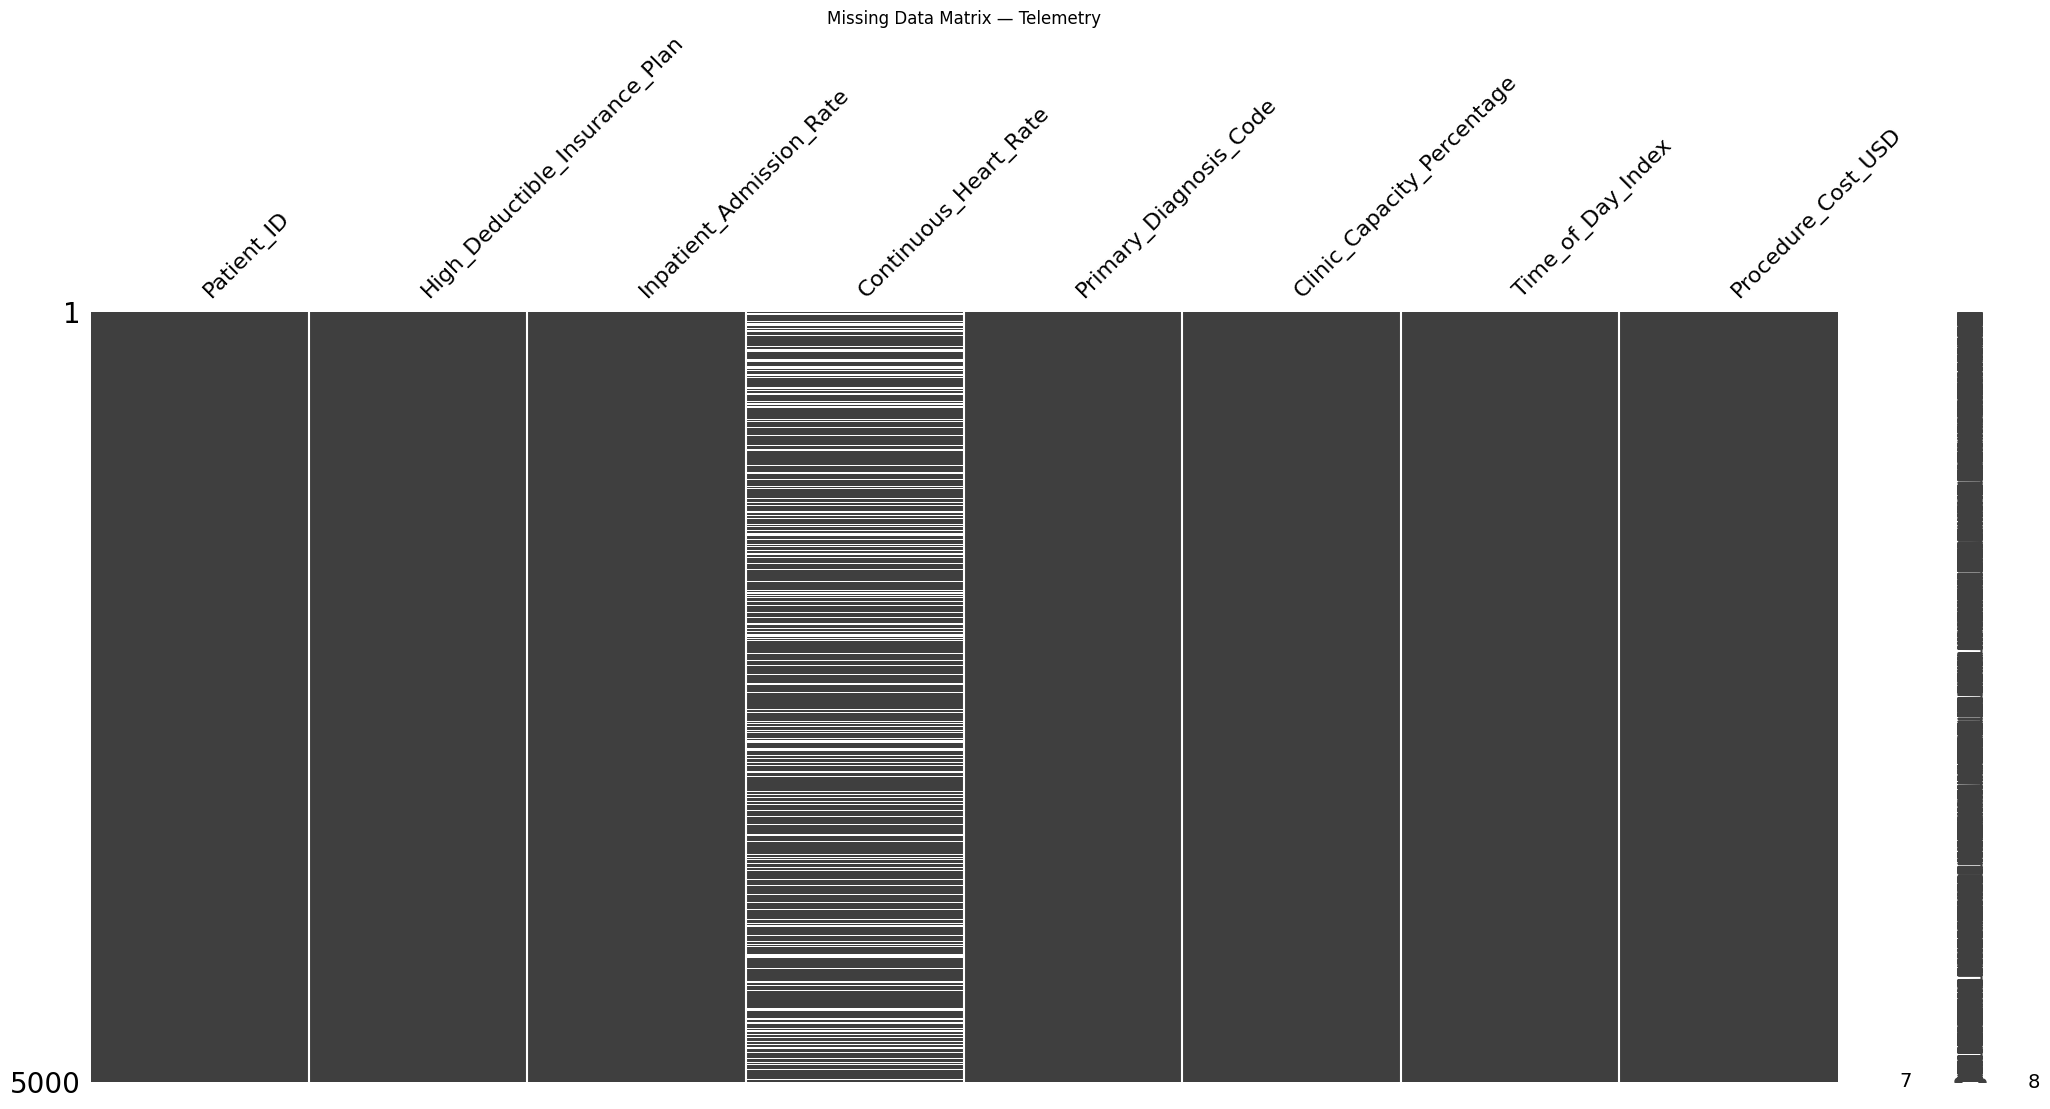

In [117]:
msno.matrix(telemetry_df)
py.title('Missing Data Matrix — Telemetry')
py.show()


This is MNAR -- Missing not at random. As stated, patients of lower SES systemically refuse the transmit telemetry due to the data-plan costs associated with continuous streaming. There is no missing at random or complete random here.

### 2.2

In [118]:
# ALL categories (crashing OLS)
dummies_full = pd.get_dummies(telemetry_df['Primary_Diagnosis_Code'], prefix='ICD10')
print(f'Dummy columns created: {dummies_full.shape[1]}')

# every row sums to exactly 1
print(dummies_full.sum(axis=1).unique())  # should print [1]

# Drop one category to break linear dependency
dummies_safe = pd.get_dummies(telemetry_df['Primary_Diagnosis_Code'], prefix='ICD10', drop_first=True)
print(f'Dummy columns after drop_first: {dummies_safe.shape[1]}')

Dummy columns created: 847
[1]
Dummy columns after drop_first: 846


If you have 847 categories, one-hot encoding gives you 847 columns where each row has exactly one 1 and the rest 0s, which means those 847 columns always sum to 1 in every row, which is exactly what the intercept column looks like.
OLS cannot handle two things in the model that contain identical information.

Dropping one dummy breaks the tie: now the 849 columns no longer sum perfectly to the intercept, the matrix is solvable, and the dropped category just becomes the silent baseline everything else is compared against.

### 2.3

In [119]:
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
telemetry_df['Primary_Diagnosis_Code_encoded'] = encoder.fit_transform(
    telemetry_df['Primary_Diagnosis_Code'],
    telemetry_df['Procedure_Cost_USD']
)

print(telemetry_df[['Primary_Diagnosis_Code', 'Primary_Diagnosis_Code_encoded']].head())

  Primary_Diagnosis_Code  Primary_Diagnosis_Code_encoded
0                J86.381                     1707.697108
1                M29.789                     1792.303198
2                E49.618                     1730.334968
3                E66.244                     1725.060944
4                J45.553                     1801.821085


## Phase 3: Architecting the Prediction Engine

### 3.1

In [120]:
df = pd.merge(vitals_df, telemetry_df, on='Patient_ID', how='inner')
print(f'Merged shape: {df.shape}')

Merged shape: (5000, 14)


### 3.2

In [121]:
df = df.drop(columns=['BMI', 'Systolic_BP', 'Primary_Diagnosis_Code'])
df = df.dropna()
print(f'Shape after cleaning: {df.shape}')

Shape after cleaning: (3786, 11)


### 3.3

In [122]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
split = int(len(df) * 0.8)
train = df.iloc[:split]
test  = df.iloc[split:]
print(f'Train: {len(train)} rows  |  Test: {len(test)} rows')

Train: 3028 rows  |  Test: 758 rows


### 3.4

In [123]:
outcome    = 'Procedure_Cost_USD'
predictors = [c for c in train.columns if c not in [outcome, 'Patient_ID']]
formula    = outcome + ' ~ ' + ' + '.join(predictors)

model = smf.ols(formula, data=train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     111.2
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.91e-180
Time:                        04:07:53   Log-Likelihood:                -21863.
No. Observations:                3028   AIC:                         4.375e+04
Df Residuals:                    3018   BIC:                         4.381e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

### 3.5

In [124]:
predictions = model.predict(test)
residuals   = test[outcome] - predictions

rmse    = np.sqrt((residuals ** 2).mean())
ss_res  = (residuals ** 2).sum()
ss_tot  = ((test[outcome] - test[outcome].mean()) ** 2).sum()
r2_oos  = 1 - (ss_res / ss_tot)

print(f'Out-of-Sample RMSE : {rmse:.4f}')
print(f'Out-of-Sample R²   : {r2_oos:.4f}')

Out-of-Sample RMSE : 343.1850
Out-of-Sample R²   : 0.2746


### 3.6

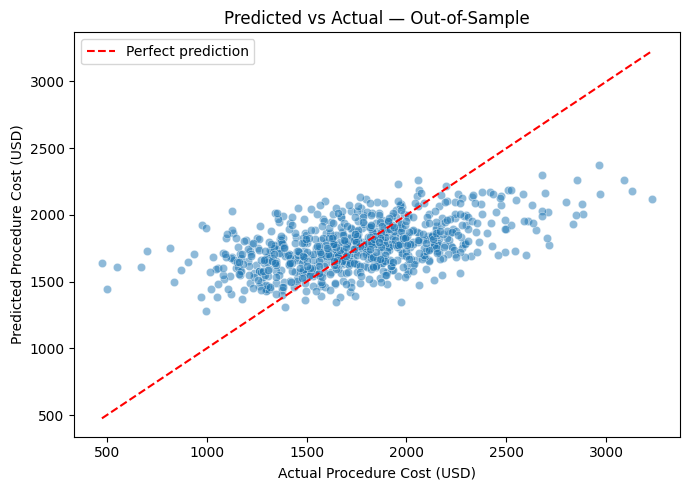

In [125]:
py.figure(figsize=(7, 5))
sns.scatterplot(x=test[outcome], y=predictions, alpha=0.5)
py.plot([test[outcome].min(), test[outcome].max()],
        [test[outcome].min(), test[outcome].max()],
        color='red', lw=1.5, ls='--', label='Perfect prediction')
py.xlabel('Actual Procedure Cost (USD)')
py.ylabel('Predicted Procedure Cost (USD)')
py.title('Predicted vs Actual — Out-of-Sample')
py.legend()
py.tight_layout()
py.show()

## Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

In [126]:
from statsmodels.stats.diagnostic import het_white

lm, lm_pvalue, fstat, f_pvalue = het_white(model.resid, model.model.exog)

print(f'White LM Statistic : {lm:.4f}')
print(f'White LM p-value   : {lm_pvalue:.4f}')

if lm_pvalue < 0.05:
    print('Conclusion: The null hypothesis of homoscedasticity is rejected at the 0.05 level — heteroscedasticity is present and OLS standard errors are unreliable.')
else:
    print('Conclusion: The null hypothesis of homoscedasticity is not rejected at the 0.05 level — no significant evidence of heteroscedasticity.')

White LM Statistic : 152.7411
White LM p-value   : 0.0000
Conclusion: The null hypothesis of homoscedasticity is rejected at the 0.05 level — heteroscedasticity is present and OLS standard errors are unreliable.
